# Car Price | EDA & Prediction

## Project Overview

This project explores a dataset containing 301 used car records with information about vehicle age, kilometers driven, present price, selling price, fuel type, seller type, transmission, and previous owners.

The analysis focuses on understanding the structure and quality of the data, exploring relationships between vehicle characteristics and selling price, investigating potential outliers, and building a Linear Regression model for selling price prediction.


## Project Objective

The main objectives of this project are to:

* Perform Exploratory Data Analysis (EDA) to understand the dataset and identify important patterns.
* Investigate relationships between vehicle characteristics and Selling Price.
* Identify and examine potential noise and outliers.
* Prepare numerical and categorical features for modeling.
* Build and evaluate Linear Regression models using different feature specifications.
* Compare candidate model specifications using cross validation on the training data.
* Generate an example prediction for a sample vehicle.

## Dataset Overview

### Feature Description

| Feature       | Description                                         |
| ------------- | --------------------------------------------------- |
| Car Name      | Name of the car model                               |
| Year          | Year in which the car was purchased                 |
| Selling_Price | Price at which the car was sold                     |
| Present_Price | Current market price of the car model               |
| Kms_Driven    | Number of kilometers driven before the car was sold |
| Fuel_Type     | Type of fuel used by the car                        |
| Seller_Type   | Type of seller                                      |
| Transmission  | Transmission type (Automatic / Manual)              |
| Owner         | Number of previous owners                           |


## Tools & Libraries

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Plotly
- Scikit-learn
- VS Code

## Workflow

1. Load and inspect the dataset
2. Check data quality, missing values, duplicates, and data types
3. Engineer a vehicle Age feature
4. Explore distributions and categorical variables
5. Investigate relationships and potential outliers
6. Prepare the data for modeling
7. Split the data into training and test sets
8. Encode categorical features and standardize numerical features within a pipeline
9. Compare Linear Regression model specifications using 5 fold cross validation
10. Evaluate the selected model on the held-out test set
11. Generate an example selling price prediction

In [1]:
#Import_Libraries

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px

#ML
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

#kFold
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

#Normalize

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import plotly.io as pio
pio.renderers.default = "plotly_mimetype+png"

In [2]:
# Load dataset

df = pd.read_csv('../data/cardata.csv')

### Dataset Information

In [3]:
df.head(5)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [5]:
#Number_of_Rows_Columns

rows,columns= df.shape
print(f"Number of rows in this dataset is: {rows}")
print(f"Number of columns in this dataset is: {columns}")

Number of rows in this dataset is: 301
Number of columns in this dataset is: 9


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


## Data Cleaning

### Missing Values

In [7]:
#missing_values_each_col

print("Number of missing values in each column :" , "\n ")
print(df.isna().sum())

#number_of_missing_values
num_of_missing_value= df.isna().sum().sum()

print(f"number of missing values : {num_of_missing_value}")

Number of missing values in each column : 
 
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64
number of missing values : 0


In this dataset we don’t have missing values, but we should also check for the presence of hidden characters and values that are used as placeholders for missing data like -, ?,...

In [8]:
(df == '?').sum().sum()

0

In [9]:
(df == '-').sum().sum()

0

No placeholders were found.

### Duplicate Records

In [10]:
#Number_of_Duplicate_Records

Num_dup = df.duplicated().sum()
print(f"There are {Num_dup} duplicated rows in this dataset.")

#Duplicated_records
df[df.duplicated(keep=False)]

There are 2 duplicated rows in this dataset.


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
15,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
17,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
51,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0
93,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0


In [11]:
#Drop_duplicate_records

df.drop_duplicates(inplace= True)

In [12]:
df.shape

(299, 9)

### Car Column

The `Car_Name` column is not used in the current analysis because the modeling approach focuses on numerical vehicle characteristics and categorical attributes such as fuel type, seller type, and transmission.


In [13]:
#drop_Car_Name_Column

df = df.drop("Car_Name", axis=1)

In [14]:
#validate

df.head(3)

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0


The dataset now contains 8 columns after removing the Car_Name field.

### Unique Values

In [15]:
#Unique_Values

for column in df.columns:
    print(f"Unique Values in '{column}':")
    print(df[column].unique())
    print("_"*40)

Unique Values in 'Year':
[2014 2013 2017 2011 2018 2015 2016 2009 2010 2012 2003 2008 2006 2005
 2004 2007]
________________________________________
Unique Values in 'Selling_Price':
[ 3.35  4.75  7.25  2.85  4.6   9.25  6.75  6.5   8.75  7.45  6.85  7.5
  6.1   2.25  7.75  3.25  2.65  4.9   4.4   2.5   2.9   3.    4.15  6.
  1.95  3.1   2.35  4.95  5.5   2.95  4.65  0.35  5.85  2.55  1.25  1.05
  5.8  14.9  23.   18.   16.    2.75  3.6   4.5   4.1  19.99  6.95 18.75
 23.5  33.   19.75  4.35 14.25  3.95  1.5   5.25 14.5  14.73 12.5   3.49
 35.    5.9   3.45  3.8  11.25  3.51  4.   20.75 17.    7.05  9.65  1.75
  1.7   1.65  1.45  1.35  1.2   1.15  1.11  1.1   1.    0.95  0.9   0.75
  0.8   0.78  0.72  0.65  0.6   0.55  0.52  0.51  0.5   0.48  0.45  0.42
  0.4   0.38  0.31  0.3   0.27  0.25  0.2   0.18  0.17  0.16  0.15  0.12
  0.1   5.75  5.15  7.9   4.85 11.75  3.15  6.45  3.5   8.25  5.11  2.7
  6.15 11.45  3.9   9.1   4.8   2.    5.35  6.25  5.95  5.2   3.75 12.9
  5.    5.4   7.2  

### Data Types

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 300
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Year           299 non-null    int64  
 1   Selling_Price  299 non-null    float64
 2   Present_Price  299 non-null    float64
 3   Kms_Driven     299 non-null    int64  
 4   Fuel_Type      299 non-null    object 
 5   Seller_Type    299 non-null    object 
 6   Transmission   299 non-null    object 
 7   Owner          299 non-null    int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 21.0+ KB


In [17]:
#Change_Data_Type

df["Fuel_Type"] = df["Fuel_Type"].astype("string")
df["Seller_Type"]= df["Seller_Type"].astype("string")
df["Transmission"] = df["Transmission"].astype("string")

### Year Column 

In [18]:
print(df["Year"].min())
print(df["Year"].max())

2003
2018


For the analysis, vehicle age is more directly interpretable than the original purchase year. Therefore, a new Age feature is created from Year.

The dataset is analyzed in the 2019 context, so vehicle age is calculated as:

**Age = 2019 − Year**

This converts the original purchase year into an easier to interpret measure of vehicle age.


In [19]:
df["Age"]= 2019 - df["Year"]

In [20]:
df["Age"]

0       5
1       6
2       2
3       8
4       5
       ..
296     3
297     4
298    10
299     2
300     3
Name: Age, Length: 299, dtype: int64

In [21]:
# Check_Age_feature

minAge = df["Age"].min()
maxAge = df["Age"].max()
typeAge = df["Age"].dtype

print("Minimum value in the Age column is:", minAge)
print("Maximum value in the Age column is:", maxAge,"\n")
print("Type of Age column is:", typeAge)

df.head(5)

Minimum value in the Age column is: 1
Maximum value in the Age column is: 16 

Type of Age column is: int64


,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,5
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,6
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,2
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,8
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,5


The original Year column is no longer required for the remaining analysis because Age contains the derived information needed for the EDA and modeling steps.

In [22]:
#Drop_Year_Column

df = df.drop("Year", axis=1)

## Data Visualization

### Distribution of Continuous Variables

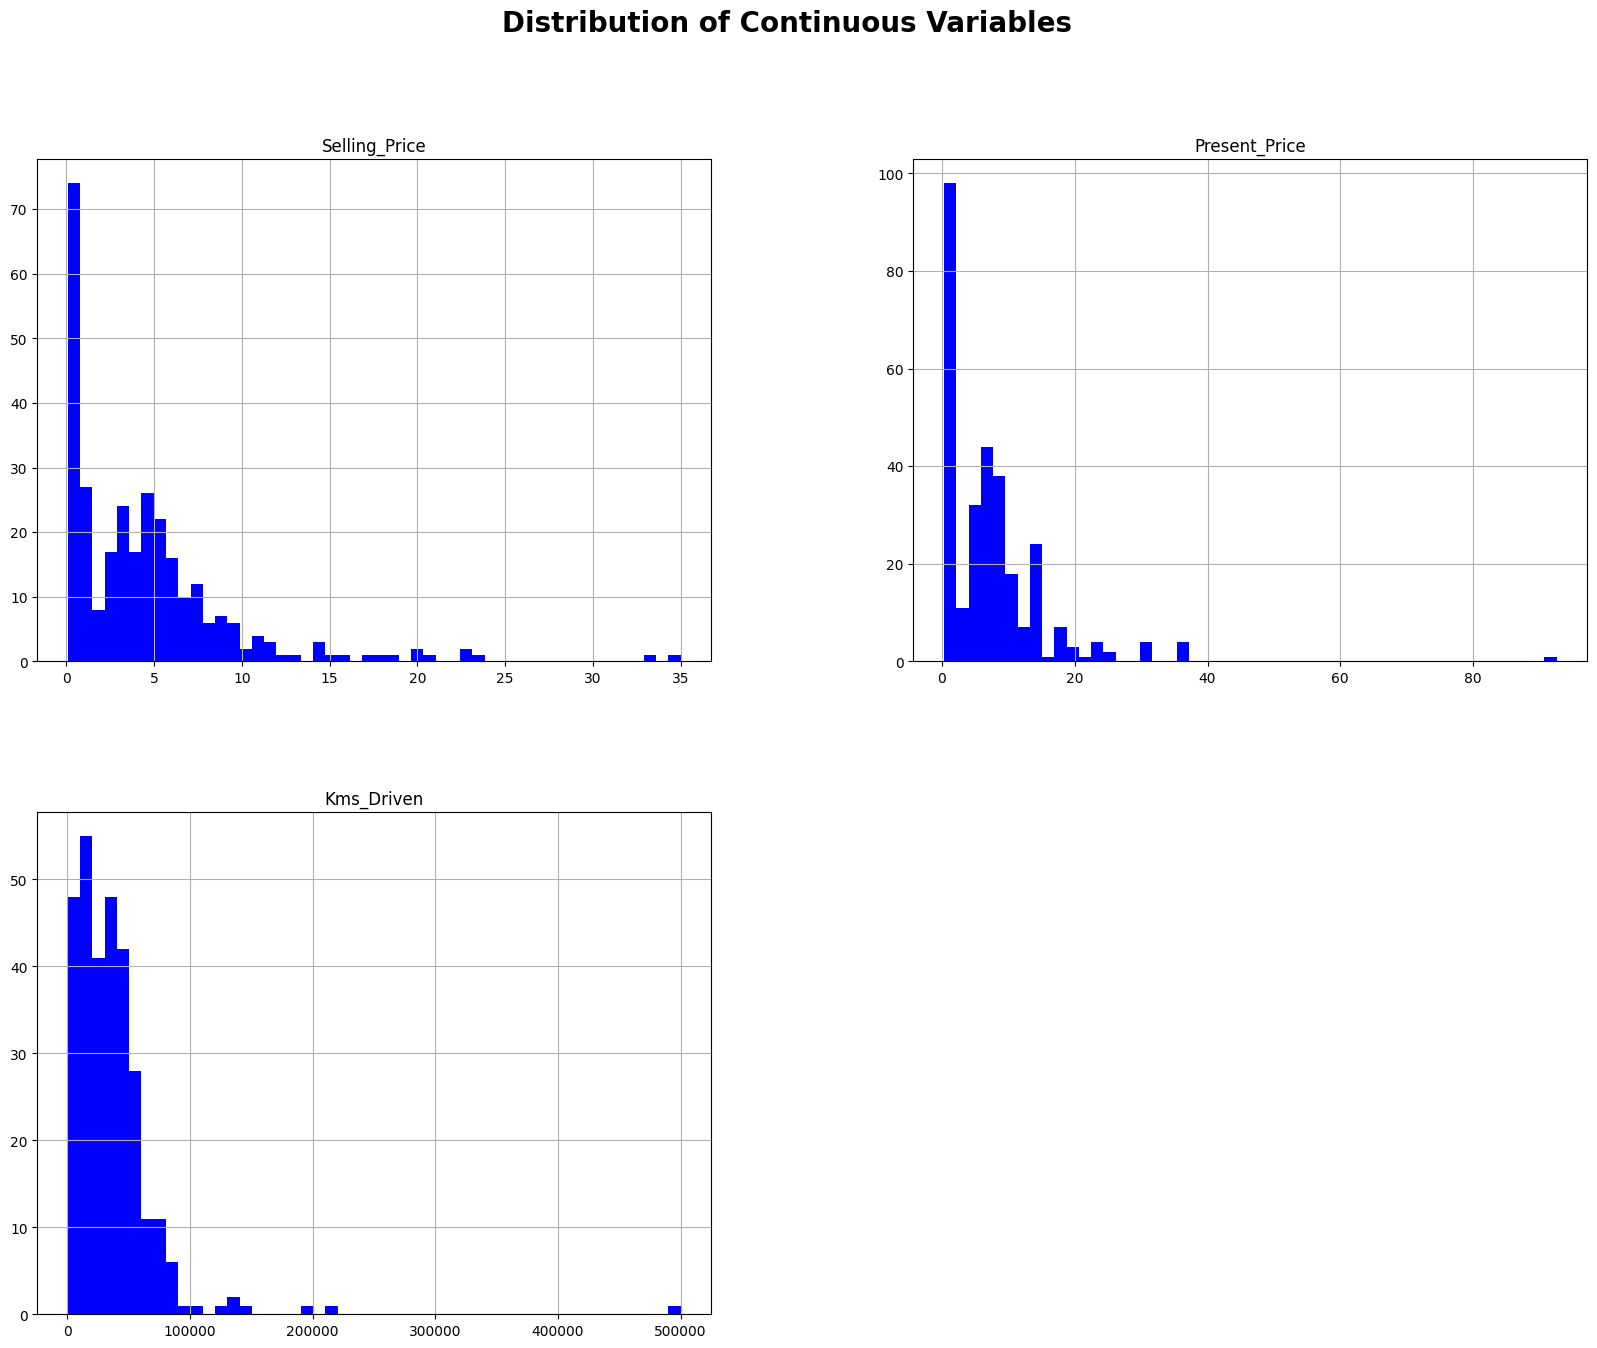

In [23]:
#Continuous_columns
continuous_cols = df[['Selling_Price', 'Present_Price', 'Kms_Driven']]

#Histogram
continuous_cols.hist(bins=50, figsize=(20, 15), color='blue')
plt.suptitle("Distribution of Continuous Variables", fontsize=20, fontweight='bold')
plt.show()


### Distribution of Age Column

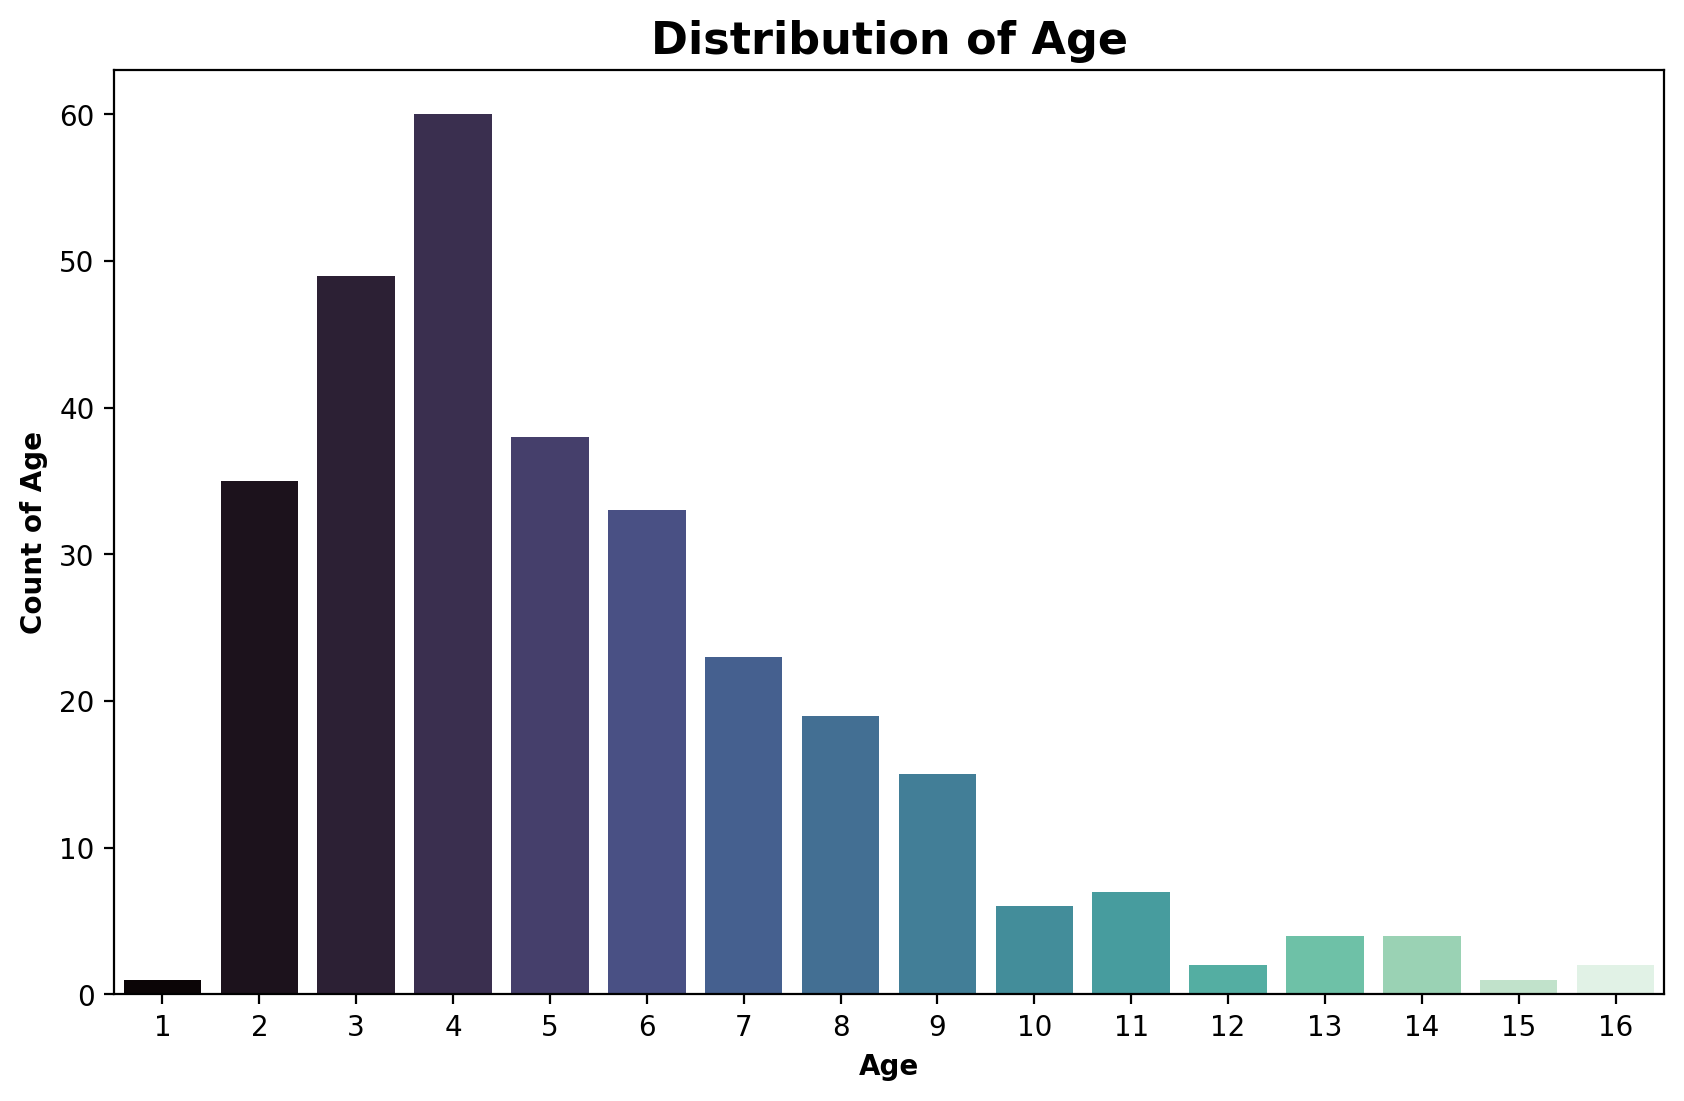

In [24]:
#Distribution_of_Age

plt.figure(figsize=(10,6), dpi=200)

ax=sns.countplot(data=df, x="Age", order=sorted(df["Age"].unique()), 
            palette="mako", hue="Age", legend=False)
plt.xlabel("Age", weight="bold")
plt.ylabel("Count of Age", weight="bold")
plt.title("Distribution of Age",weight="bold", fontsize=16)
plt.show()

The vehicles in this dataset range from 1 to 16 years old.

Most observations fall between 2 and 9 years of age. Vehicles with an age of 4 years are the most common, with 60 observations.


### Fuel Type Distribution

In [25]:
df["Fuel_Type"].value_counts()

Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: Int64

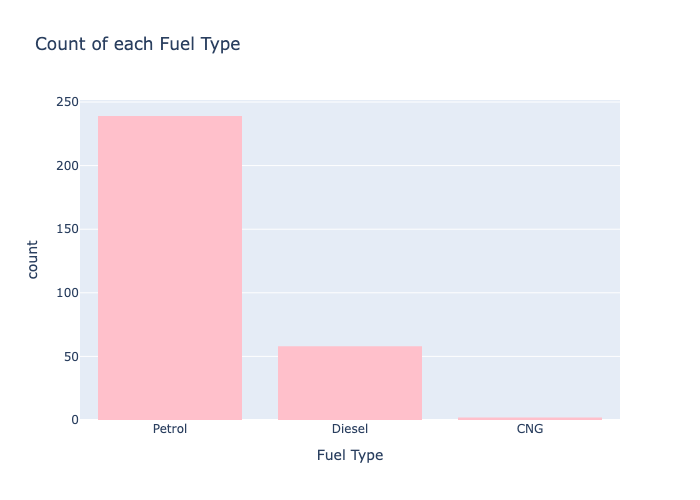

In [26]:
#Count_Fuel_Type

fig = px.histogram(df, x='Fuel_Type',
                labels = {'Fuel_Type':'Fuel Type'},
                title = 'Count of each Fuel Type',
                color_discrete_sequence= ['pink'])
fig.show()

The dataset contains three fuel types.

Petrol is the most common category with 239 records, followed by Diesel with 58 records and CNG with 2 records.

The strong imbalance toward Petrol should be considered when interpreting comparisons between fuel types.


### Seller Type Distribution

In [27]:
#Seller_Type

df["Seller_Type"].value_counts()

Seller_Type
Dealer        193
Individual    106
Name: count, dtype: Int64

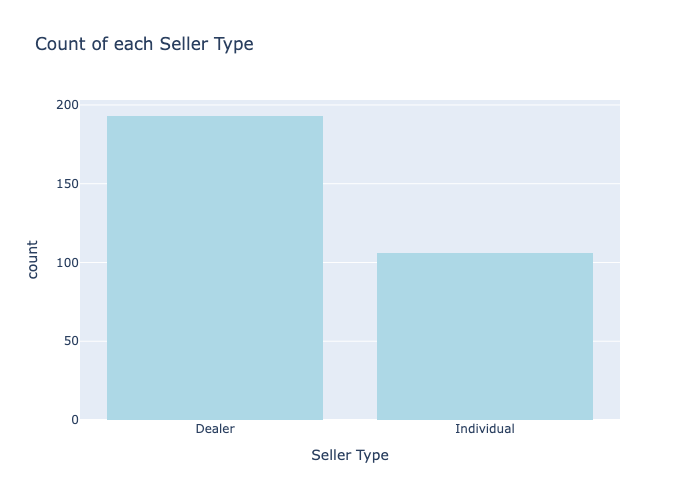

In [28]:
#Count_Seller_Type

fig = px.histogram(df, x='Seller_Type',
                labels = {'Seller_Type':'Seller Type'},
                title = 'Count of each Seller Type',
                color_discrete_sequence= ["lightblue"])
fig.show()

Among the 299 records remaining after duplicate removal, 193 cars are listed by dealers, while 106 are listed by individual sellers.

### Count of Transmission

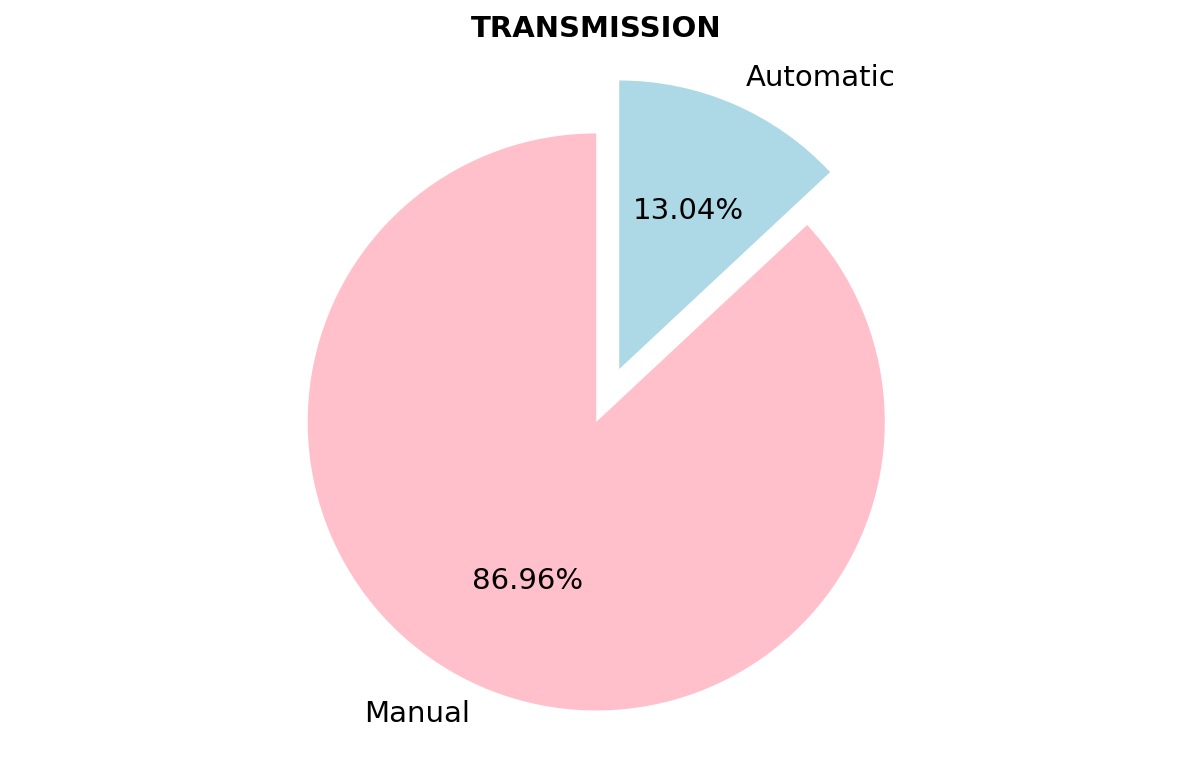

In [29]:
#Count_Transmission

Transmission_count =df['Transmission'].value_counts()

plt.figure(figsize=(10,6), dpi=150)
plt.pie(Transmission_count,labels=Transmission_count.index,explode=[0.1,0.1],
        autopct="%1.2f%%",colors=['pink','lightblue'], startangle=90,
        textprops={'fontsize': 14})

plt.title('TRANSMISSION', fontsize=14, weight="bold")
plt.axis('equal')


plt.show()



87.8% of the cars have manual transmission, while 12.2% are automatic.

## Potential Noise & Outliers

### Selling Price vs. Kilometers Driven

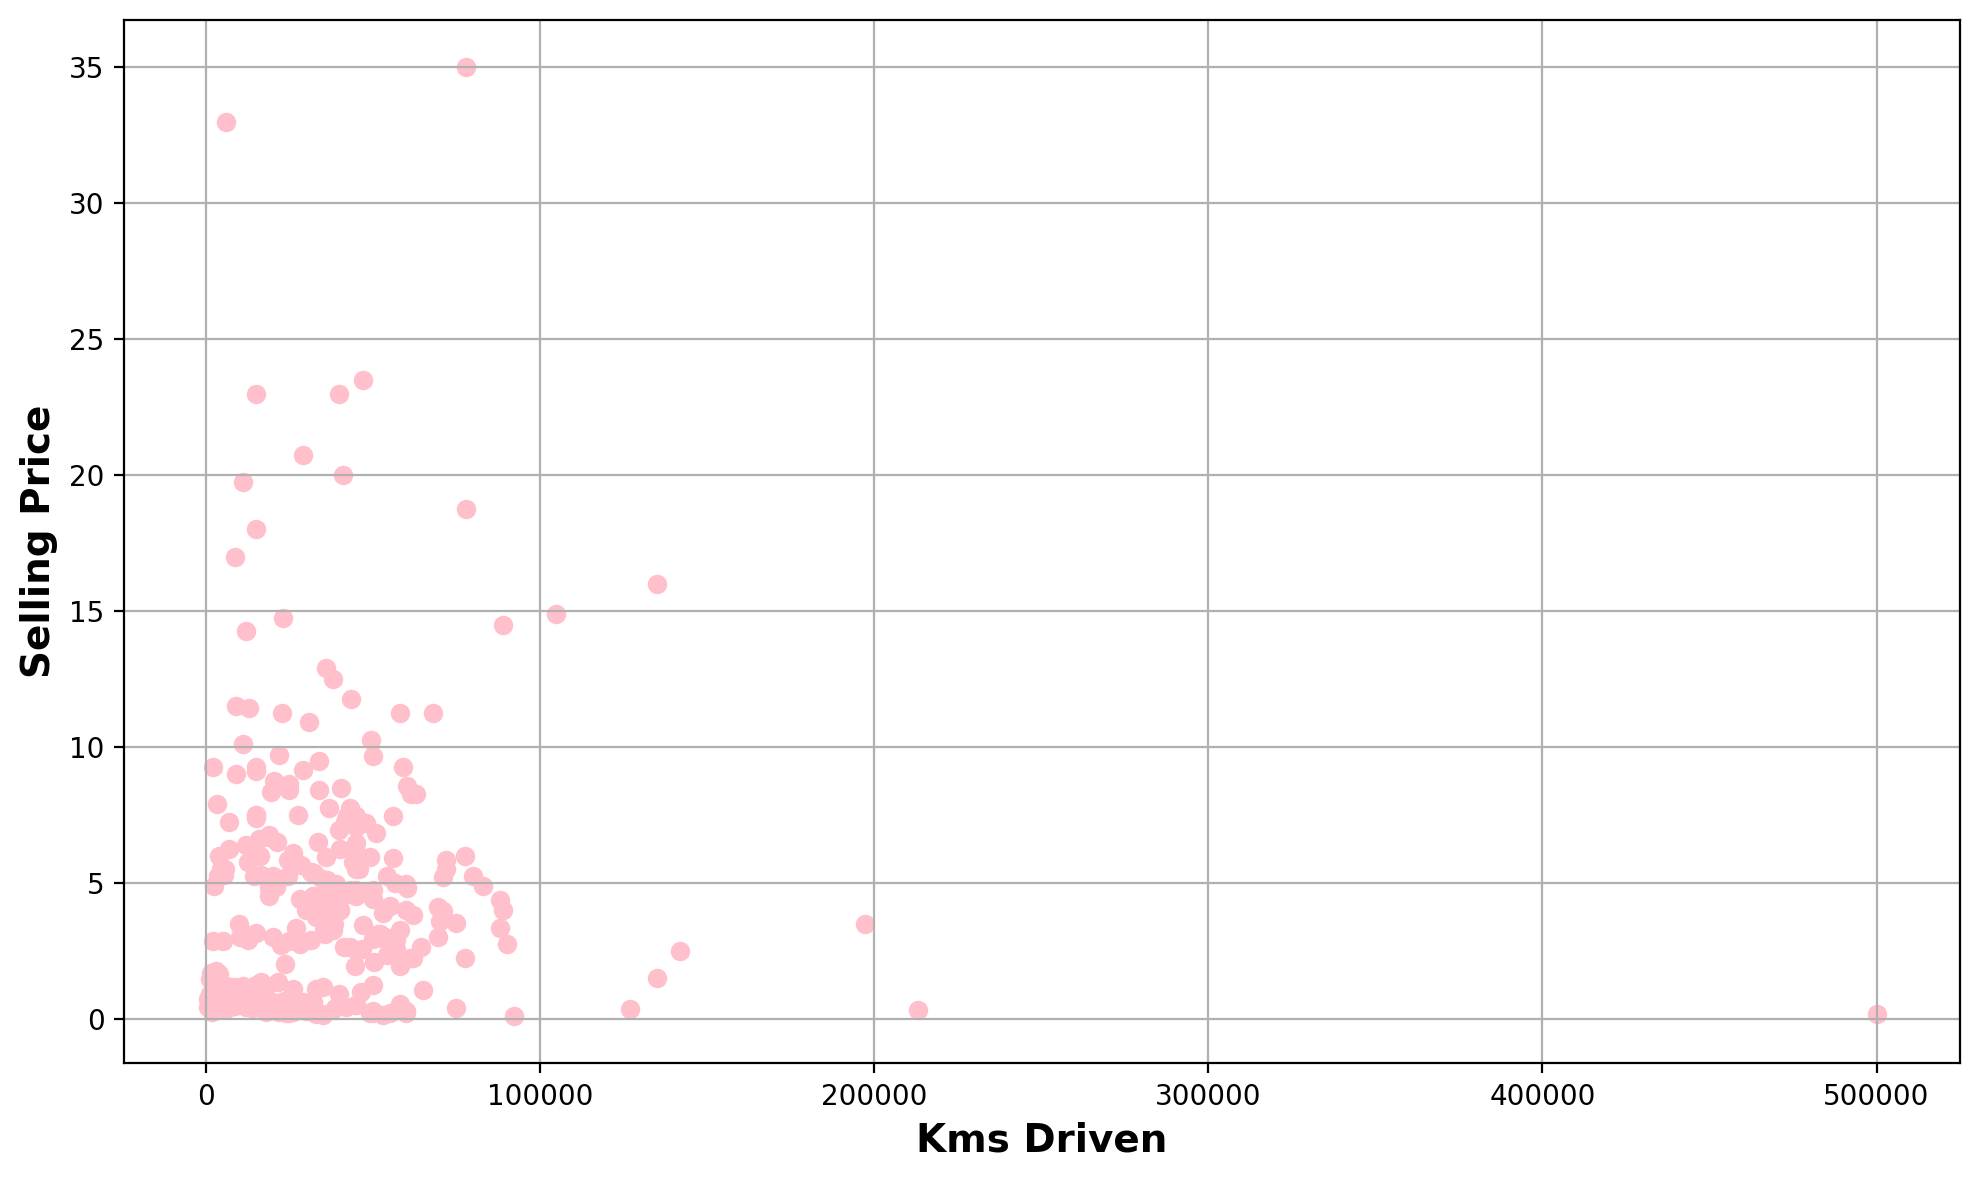

In [30]:
#Selling_Price_Vs_Kms_Driven

plt.figure(figsize=(10,6), dpi=200)
plt.scatter(df["Kms_Driven"], df["Selling_Price"], color='pink')

plt.xlabel("Kms Driven", fontsize=14, weight='bold')
plt.ylabel("Selling Price", fontsize=14, weight='bold')

plt.tight_layout()
plt.grid()
plt.show()

In [31]:
# Remove potential Kms_Driven outlier above 400,000

df[df["Kms_Driven"] > 400000]

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
196,0.17,0.52,500000,Petrol,Individual,Automatic,0,11


### Kilometers Driven VS Vehicle Age

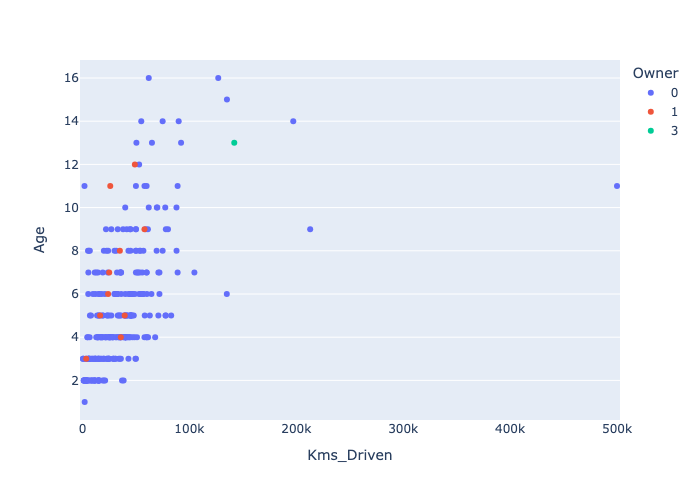

In [32]:
#Kms_Driven_Vs_Age
#Colored_by_Owner

fig = px.strip(df, x='Kms_Driven', y='Age', color='Owner')
fig.show()

### Selling Price vs. Kilometers Driven by Owner

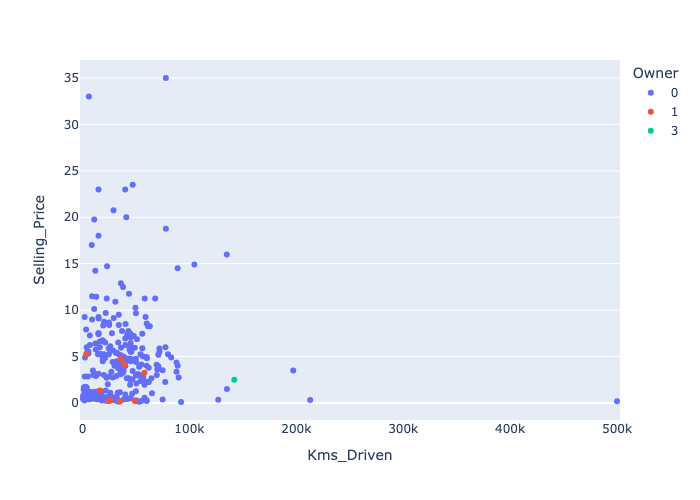

In [33]:
#Kms_Driven_Vs_Selling_Price
#Colored_by_Owner

fig = px.strip(df, x='Kms_Driven', y='Selling_Price', color='Owner')
fig.show()

In [34]:
#Drop Kms_Driven > 400,000

df_new= df.drop(df[df["Kms_Driven"] >400000].index)

### Selling Price vs. Kilometers Driven After Outlier Filtering

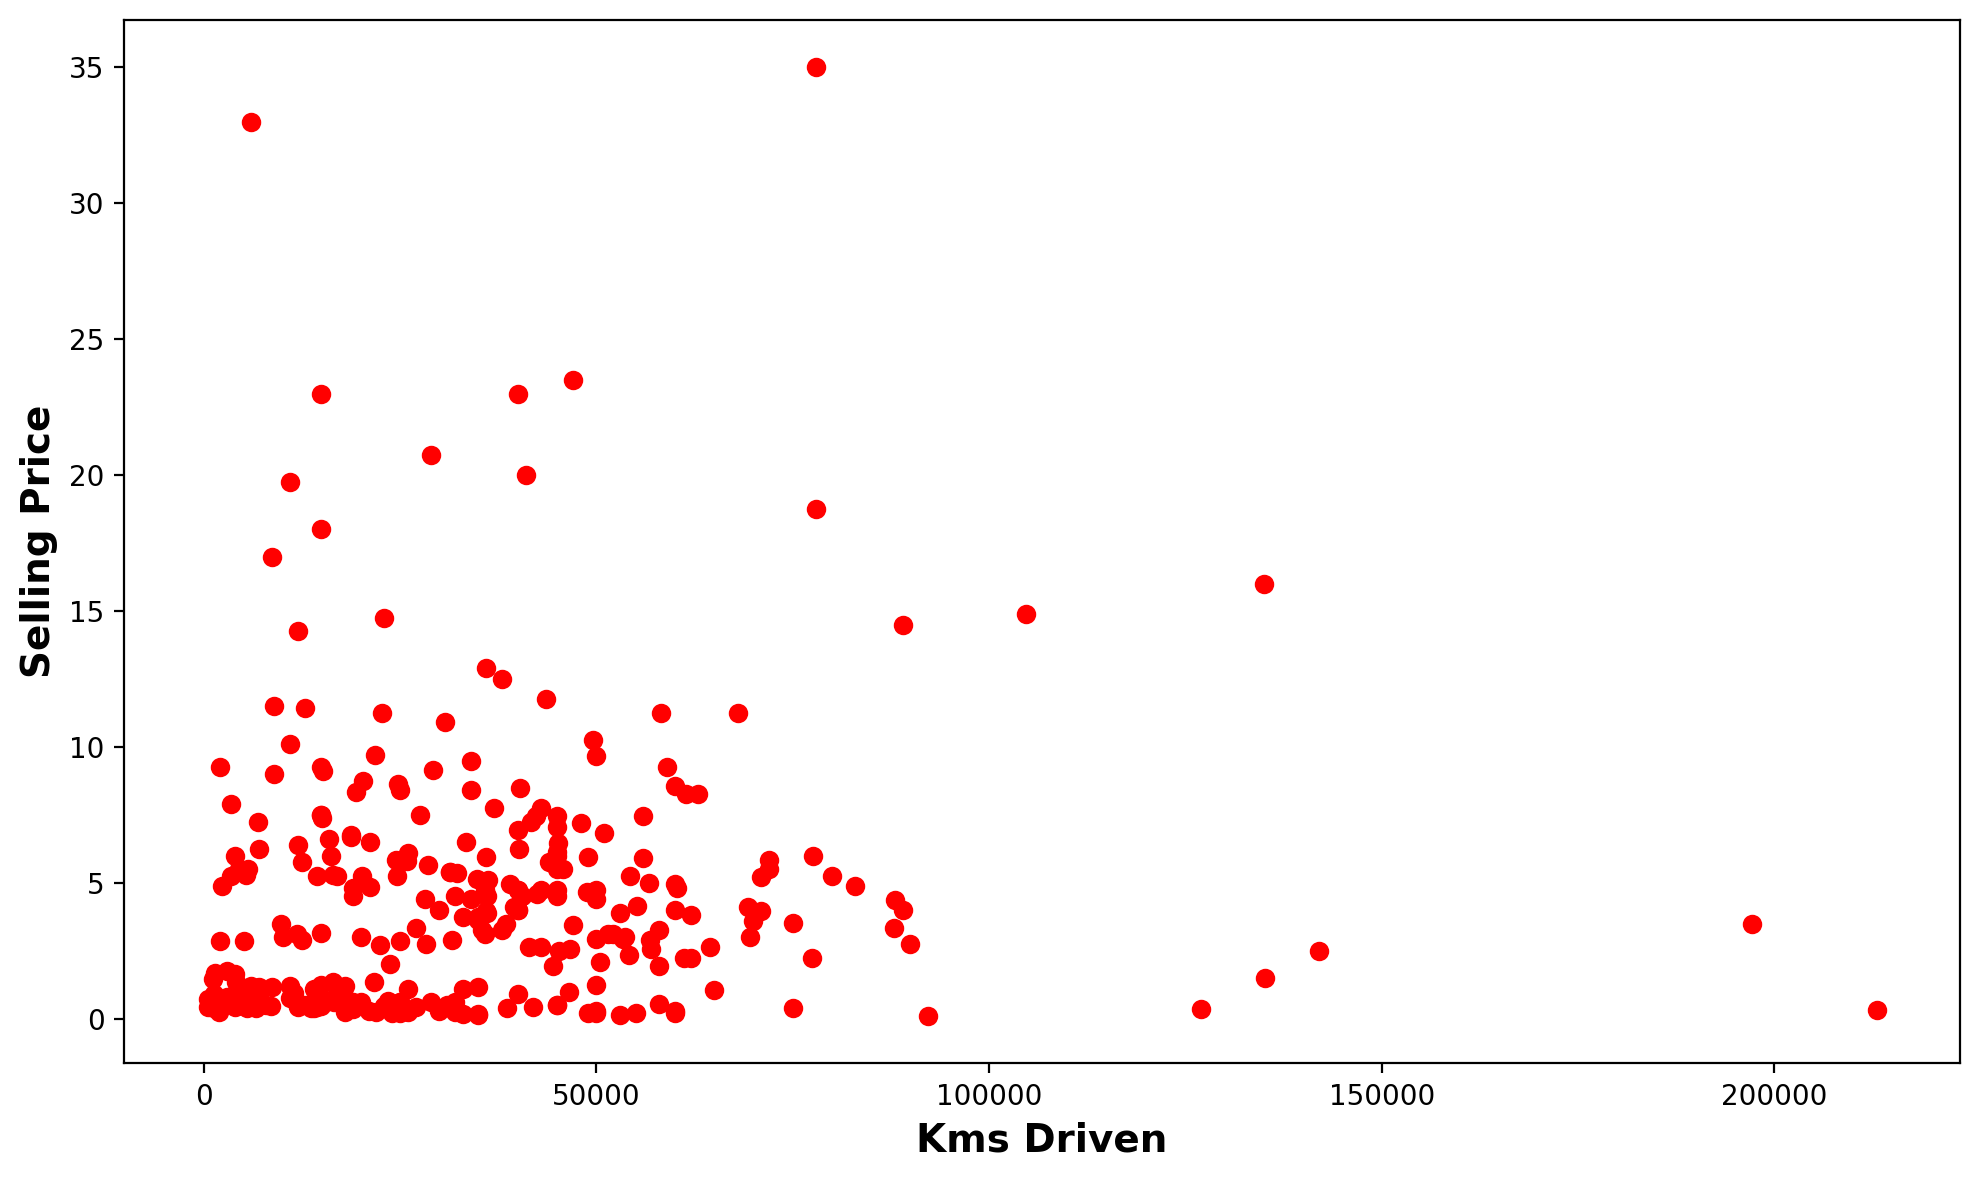

In [35]:
#Selling_Price_Vs_Kms_Driven

plt.figure(figsize=(10,6), dpi=200)
plt.scatter(df_new["Kms_Driven"], df_new["Selling_Price"], color='red')

plt.grid()
plt.xlabel("Kms Driven", fontsize=14, weight='bold')
plt.ylabel("Selling Price", fontsize=14, weight='bold')

plt.grid()
plt.tight_layout()
plt.show()

In [36]:
#Selling_Price_above_25

df_new[df_new["Selling_Price"] > 25]

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
64,33.0,36.23,6000,Diesel,Dealer,Automatic,0,2
86,35.0,92.60,78000,Diesel,Dealer,Manual,0,9


In [37]:
#Drop_Noise_Selling_Price

df_new = df_new.drop(df_new[df_new["Selling_Price"] > 25].index)

### Selling Price vs. Vehicle Age

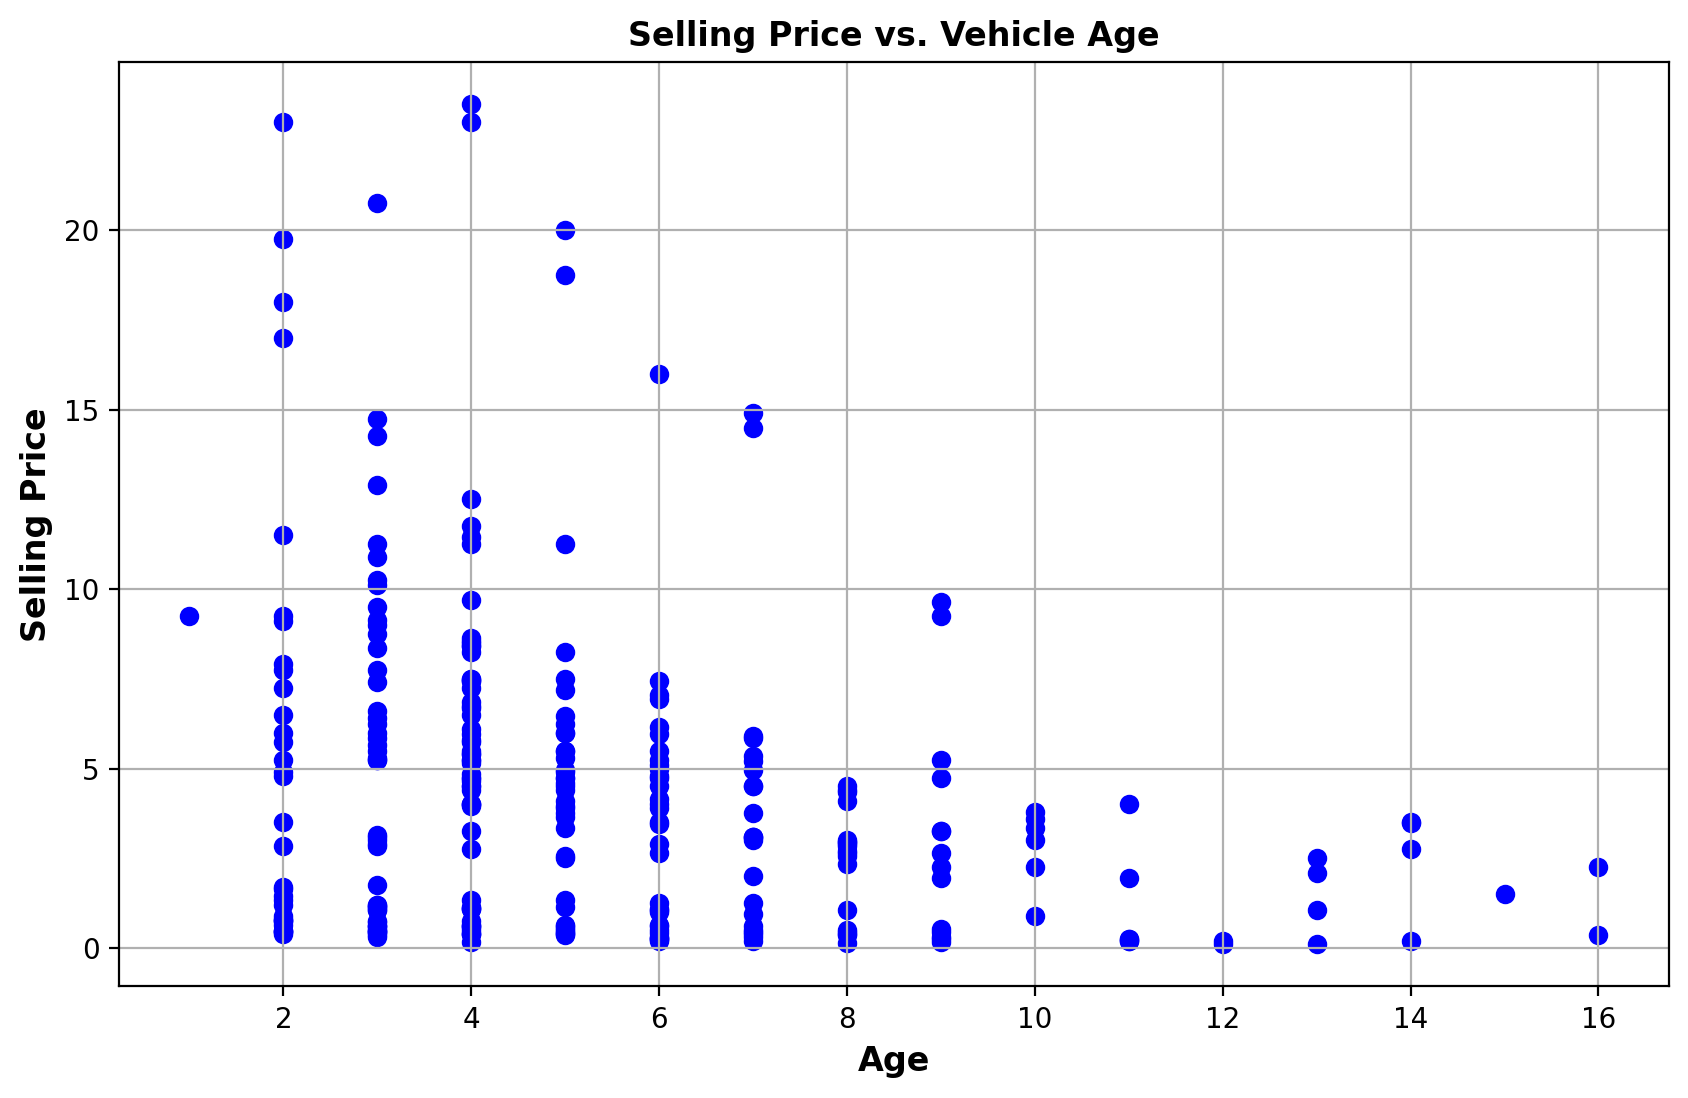

In [38]:
#Selling_Price_Vs_Age

plt.figure(figsize=(10,6), dpi=200)
plt.scatter(df_new["Age"],df_new["Selling_Price"], color='blue')

plt.xlabel("Age",fontsize=12, weight="bold")
plt.ylabel("Selling Price",fontsize=12, weight="bold")
plt.title("Selling Price vs. Vehicle Age",fontsize=12, weight="bold")

plt.grid()
plt.show()

- The scatter plot shows a general negative relationship between vehicle age and Selling Price: older vehicles tend to have lower observed selling prices in this dataset.

- The plot also highlights a small number of observations that require further investigation as potential outliers or unusual records.

### Selling Price Vs Age | Colored by Fuel Type

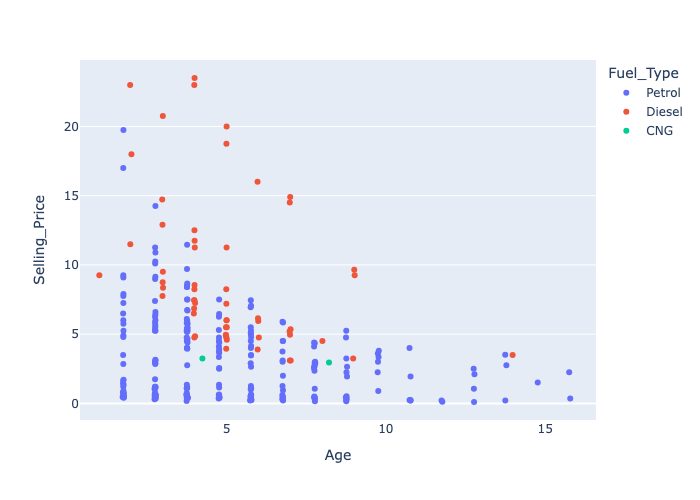

In [39]:
fig = px.strip(df_new, x='Age', y='Selling_Price', color='Fuel_Type')
fig.show()

### Present Price vs. Vehicle Age

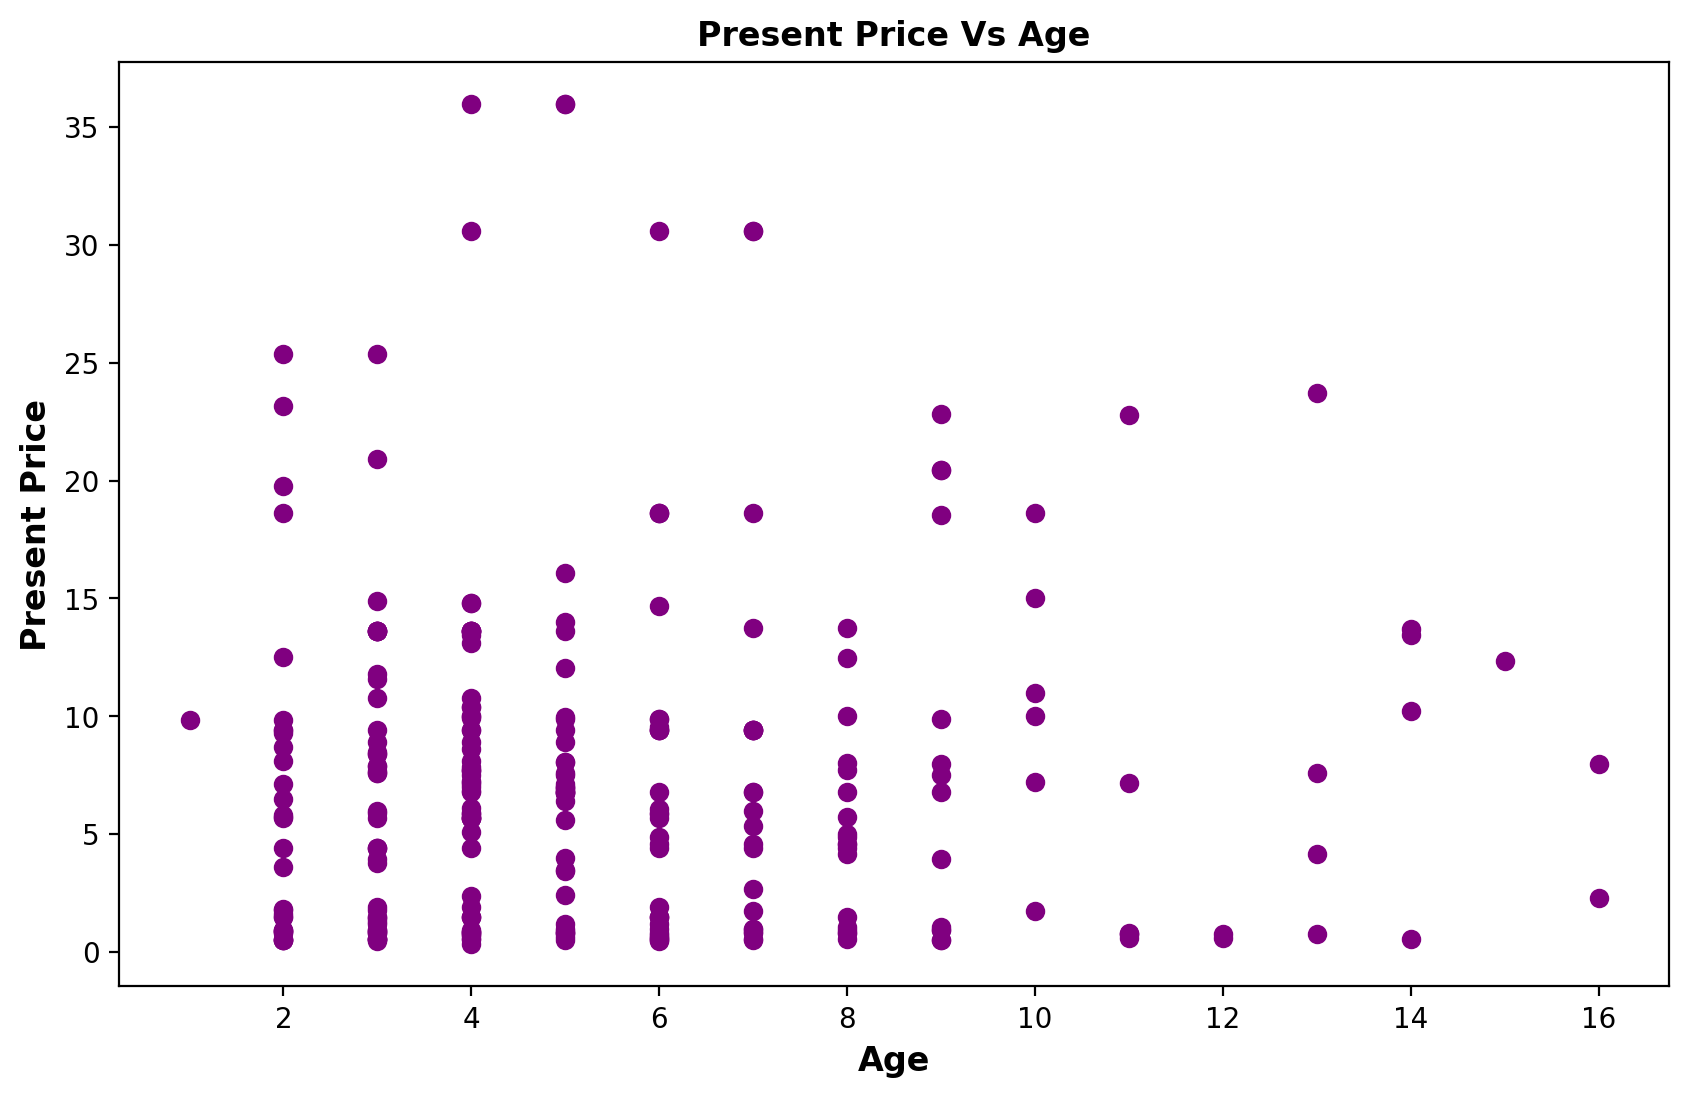

In [40]:
#Present_Price_Vs_Age

plt.figure(figsize=(10,6), dpi=200)
plt.scatter(df_new["Age"],df_new["Present_Price"], color='purple')

plt.xlabel("Age",fontsize=12, weight="bold")
plt.ylabel("Present Price",fontsize=12, weight="bold")
plt.title("Present Price Vs Age",fontsize=12, weight="bold")

plt.show()

In [41]:
df_new[df_new["Present_Price"]>40]

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age


The scatter plot shows a general negative relationship between vehicle age and Present Price: older vehicles tend to have lower observed present prices in this dataset.

The plot also highlights the overall downward pattern between vehicle age and present price after the earlier outlier filtering steps.


### Selling Price Vs Owner | Colored by Seller Type

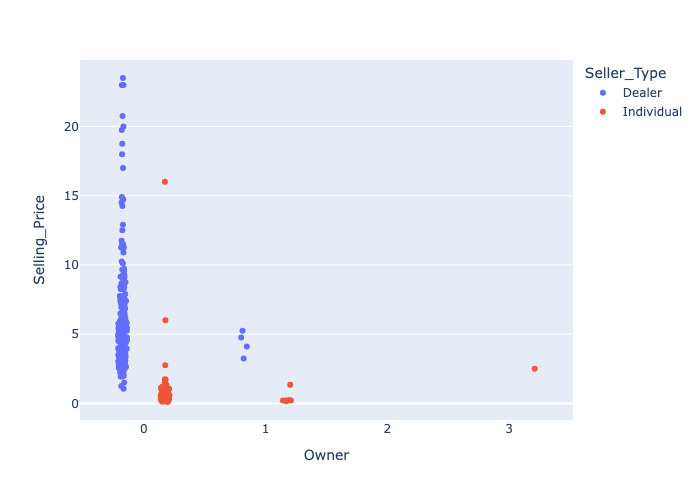

In [42]:
#Selling_Price_Vs_Owner
#Colored_by_Seller_Type

fig = px.strip(df_new, x='Owner', y='Selling_Price', color='Seller_Type')
fig.show()

Only one observation has Owner = 3, making this category too sparse for a meaningful group-level analysis in this small dataset. Therefore, this observation is excluded from the modeling dataset to avoid relying on an extremely sparse category.


In [43]:
df_new = df_new.drop(df_new[df_new["Owner"] ==3].index)

### Selling Price vs. Transmission by Owner

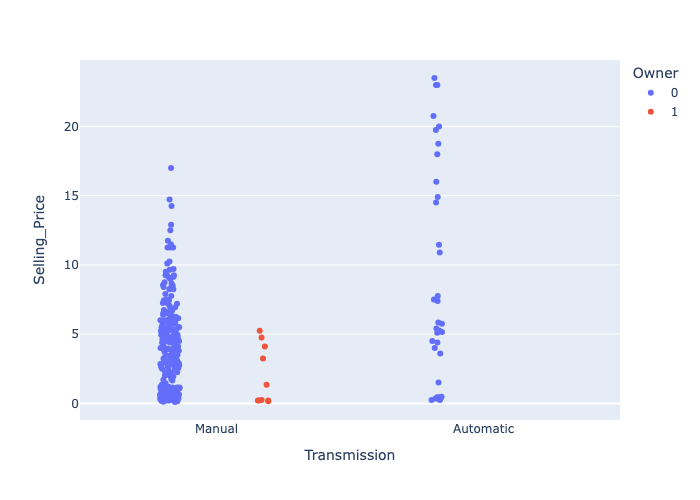

In [44]:
#Selling_Price_Vs_Transmission
#Colored_by_Owner

fig = px.strip(df_new, x='Transmission', y='Selling_Price', color='Owner')
fig.show()

In the filtered dataset, all observations with Automatic transmission have zero previous owners. This pattern is specific to the sample and should be considered when interpreting the relationship between transmission type and selling price.

### Selling Price vs. Transmission by Fuel Type

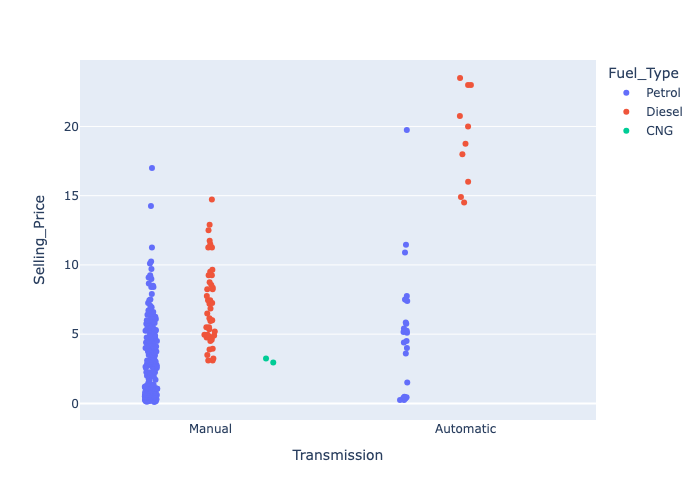

In [45]:
#Selling_Price_Vs_Transmission
#Colored_by_Fuel_Type

fig = px.strip(df_new, x='Transmission', y='Selling_Price', color='Fuel_Type')
fig.show()

Automatic Diesel cars have the highest observed selling prices among the groups shown in the plot.

However, this is a descriptive relationship and does not imply that Diesel fuel causes higher selling prices. Other factors, such as Present Price, vehicle age, and kilometers driven", may also contribute to the observed differences.


## Data Preparation for Modeling

In [46]:
# Create modeling dataset after EDA-based filtering
df3 = df_new.copy()

### Comparison of Filtered and Unfiltered Data

In [47]:
removed = df.loc[~df.index.isin(df3.index)]
print(f"Before filtering: {len(df)} rows | Modeling dataset: {len(df3)} rows | Removed: {len(removed)}")
removed

Before filtering: 299 rows | Modeling dataset: 295 rows | Removed: 4


,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
64,33.00,36.23,6000,Diesel,Dealer,Automatic,0,2
85,2.50,23.73,142000,Petrol,Individual,Automatic,3,13
86,35.00,92.60,78000,Diesel,Dealer,Manual,0,9
196,0.17,0.52,500000,Petrol,Individual,Automatic,0,11


After removing duplicates, the dataset contained 299 observations. Based on the EDA above, 4 observations (about 1.3%) were excluded to create the modeling dataset `df3` (295 rows):

- **1 car with 500,000 km driven:** extreme kilometers driven far outside the rest of the data.
- **2 cars with Selling Price above 25:** only two such records, both far from the bulk of the data, so the model cannot learn this price range reliably.
- **1 car with Owner = 3:** a single observation, too sparse to support a category.

The removed observations are listed in the cell above. Because the excluded cars are the most extreme ones, the model should be interpreted for typical used cars, not for very high-priced vehicles.

## Modeling

The modeling dataset is `df3`, which contains the observations retained after the EDA-based filtering above.

For the predictive models, preprocessing is performed inside a pipeline after the train-test split. This prevents the test set from influencing scaling or categorical encoding.

In [48]:
# Prepare raw features and target

features = ['Present_Price', 'Kms_Driven', 'Fuel_Type',
            'Seller_Type', 'Transmission', 'Owner', 'Age']

X = df3[features].copy()
y = df3['Selling_Price'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0)

### Encoding Categorical Features

Categorical variables are one-hot encoded for the regression model so that the categories are not treated as having an artificial numerical order. Numerical variables are standardized inside the modeling pipeline.

In [49]:

numeric_features = ['Present_Price', 'Kms_Driven', 'Owner', 'Age']
categorical_features = ['Fuel_Type', 'Seller_Type', 'Transmission']

def make_pipeline(numeric_columns):
    preprocessor = ColumnTransformer(
        transformers=[
            ('numeric', StandardScaler(), numeric_columns),
            ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        ]
    )
    return Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ])

## Correlation

For the correlation analysis, categorical variables are temporarily encoded only to make a numeric correlation matrix possible. These encoded values are **not** used as the categorical representation in the final regression model.

In [50]:
#Exploratory correlation encoding (not used by the final model)

correlation_df = df3.copy()
correlation_df['Fuel_Type_Code'] = correlation_df['Fuel_Type'].map({'Petrol': 2, 'Diesel': 3, 'CNG': 4})
correlation_df['Seller_Type_Code'] = correlation_df['Seller_Type'].map({'Dealer': 2, 'Individual': 3})
correlation_df['Transmission_Code'] = correlation_df['Transmission'].map({'Manual': 2, 'Automatic': 3})

correlation_columns = [
    'Present_Price', 'Kms_Driven', 'Fuel_Type_Code', 'Seller_Type_Code',
    'Transmission_Code', 'Owner', 'Age', 'Selling_Price'
]

corr_matrix = correlation_df[correlation_columns].corr()
corr_matrix

,Present_Price,Kms_Driven,Fuel_Type_Code,Seller_Type_Code,Transmission_Code,Owner,Age,Selling_Price
Present_Price,1.000000,0.348513,0.451398,-0.621787,0.406442,-0.105629,0.016992,0.887737
Kms_Driven,0.348513,1.000000,0.272471,-0.238538,0.066129,-0.025281,0.606227,0.096951
Fuel_Type_Code,0.451398,0.272471,1.000000,-0.341238,0.066186,-0.046218,-0.040787,0.491531
Seller_Type_Code,-0.621787,-0.238538,-0.341238,1.000000,-0.080019,0.097021,0.016829,-0.599256
Transmission_Code,0.406442,0.066129,0.066186,-0.080019,1.000000,-0.069836,-0.026230,0.377336
Owner,-0.105629,-0.025281,-0.046218,0.097021,-0.069836,1.000000,0.109400,-0.104647
Age,0.016992,0.606227,-0.040787,0.016829,-0.026230,0.109400,1.000000,-0.268245
Selling_Price,0.887737,0.096951,0.491531,-0.599256,0.377336,-0.104647,-0.268245,1.000000


### Correlation Ranking 

In [51]:
corr_matrix['Selling_Price'].sort_values(ascending=False)

Selling_Price        1.000000
Present_Price        0.887737
Fuel_Type_Code       0.491531
Transmission_Code    0.377336
Kms_Driven           0.096951
Owner               -0.104647
Age                 -0.268245
Seller_Type_Code    -0.599256
Name: Selling_Price, dtype: float64

Present Price shows the strongest linear association with Selling Price among the variables examined. The categorical correlations are exploratory only because the temporary numeric codes introduce an artificial ordering.

## Model Selection with Cross-Validation

The candidate models are compared using 5 fold cross validation on the training data. The test set is kept untouched until the final evaluation.

In [52]:
#Create deterministic polynomial features from Present_Price.
#These transformations do not use information from other observations.

X_train_candidates = X_train.copy()
X_test_candidates = X_test.copy()

X_train_candidates['Present_Price_square'] = X_train_candidates['Present_Price'] ** 2
X_train_candidates['Present_Price_cube'] = X_train_candidates['Present_Price'] ** 3
X_test_candidates['Present_Price_square'] = X_test_candidates['Present_Price'] ** 2
X_test_candidates['Present_Price_cube'] = X_test_candidates['Present_Price'] ** 3

cv = KFold(n_splits=5, shuffle=True, random_state=0)

model_candidates = {
    'Baseline Linear Regression': (
        make_pipeline(numeric_features), X_train
    ),
    'Present_Price²': (
        make_pipeline(numeric_features + ['Present_Price_square']), X_train_candidates
    ),
    'Present_Price³': (
        make_pipeline(numeric_features + ['Present_Price_cube']), X_train_candidates
    )
}

cv_results = []

for name, (model, X_candidate) in model_candidates.items():
    scores = cross_val_score(model, X_candidate, y_train, cv=cv, scoring='r2')
    cv_results.append({
        'Model': name,
        'Mean CV R2': scores.mean(),
        'Std CV R2': scores.std()
    })

cv_results = (
    pd.DataFrame(cv_results)
    .sort_values('Mean CV R2', ascending=False)
    .reset_index(drop=True)
)

cv_results

,Model,Mean CV R2,Std CV R2
0,Baseline Linear Regression,0.882176,0.011973
1,Present_Price²,0.879929,0.011829
2,Present_Price³,0.879864,0.011935


The model with the highest mean cross-validated R² is selected for the final fit. The test set is not used in this selection.

In [53]:
best_model_name = cv_results.loc[0, 'Model']

if best_model_name == 'Baseline Linear Regression':
    final_model = make_pipeline(numeric_features)
    X_train_final = X_train.copy()
    X_test_final = X_test.copy()
elif best_model_name == 'Present_Price²':
    final_model = make_pipeline(numeric_features + ['Present_Price_square'])
    X_train_final = X_train_candidates.copy()
    X_test_final = X_test_candidates.copy()
else:
    final_model = make_pipeline(numeric_features + ['Present_Price_cube'])
    X_train_final = X_train_candidates.copy()
    X_test_final = X_test_candidates.copy()

final_model.fit(X_train_final, y_train)
y_pred = final_model.predict(X_test_final)

print('Selected model:', best_model_name)

Selected model: Baseline Linear Regression


## Final Model Evaluation

In [54]:
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred)

print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('R2 Score:', r2)

Mean Absolute Error: 1.0144308625654967
Mean Squared Error: 2.2339640150689735
Root Mean Squared Error: 1.4946451134195613
R2 Score: 0.8646019619971842


In [55]:
#Compare actual and predicted values

compare = pd.DataFrame({'Actual': y_test.to_numpy(),'Predict': y_pred})
compare

,Actual,Predict
0,3.10,4.054765
1,5.50,4.497955
2,7.50,6.878461
3,4.50,4.410530
4,4.10,4.410162
5,2.65,2.535943
6,5.95,6.634256
7,4.50,4.725799
8,4.50,4.937686
9,4.75,5.774781


### Actual vs Predicted Selling Price

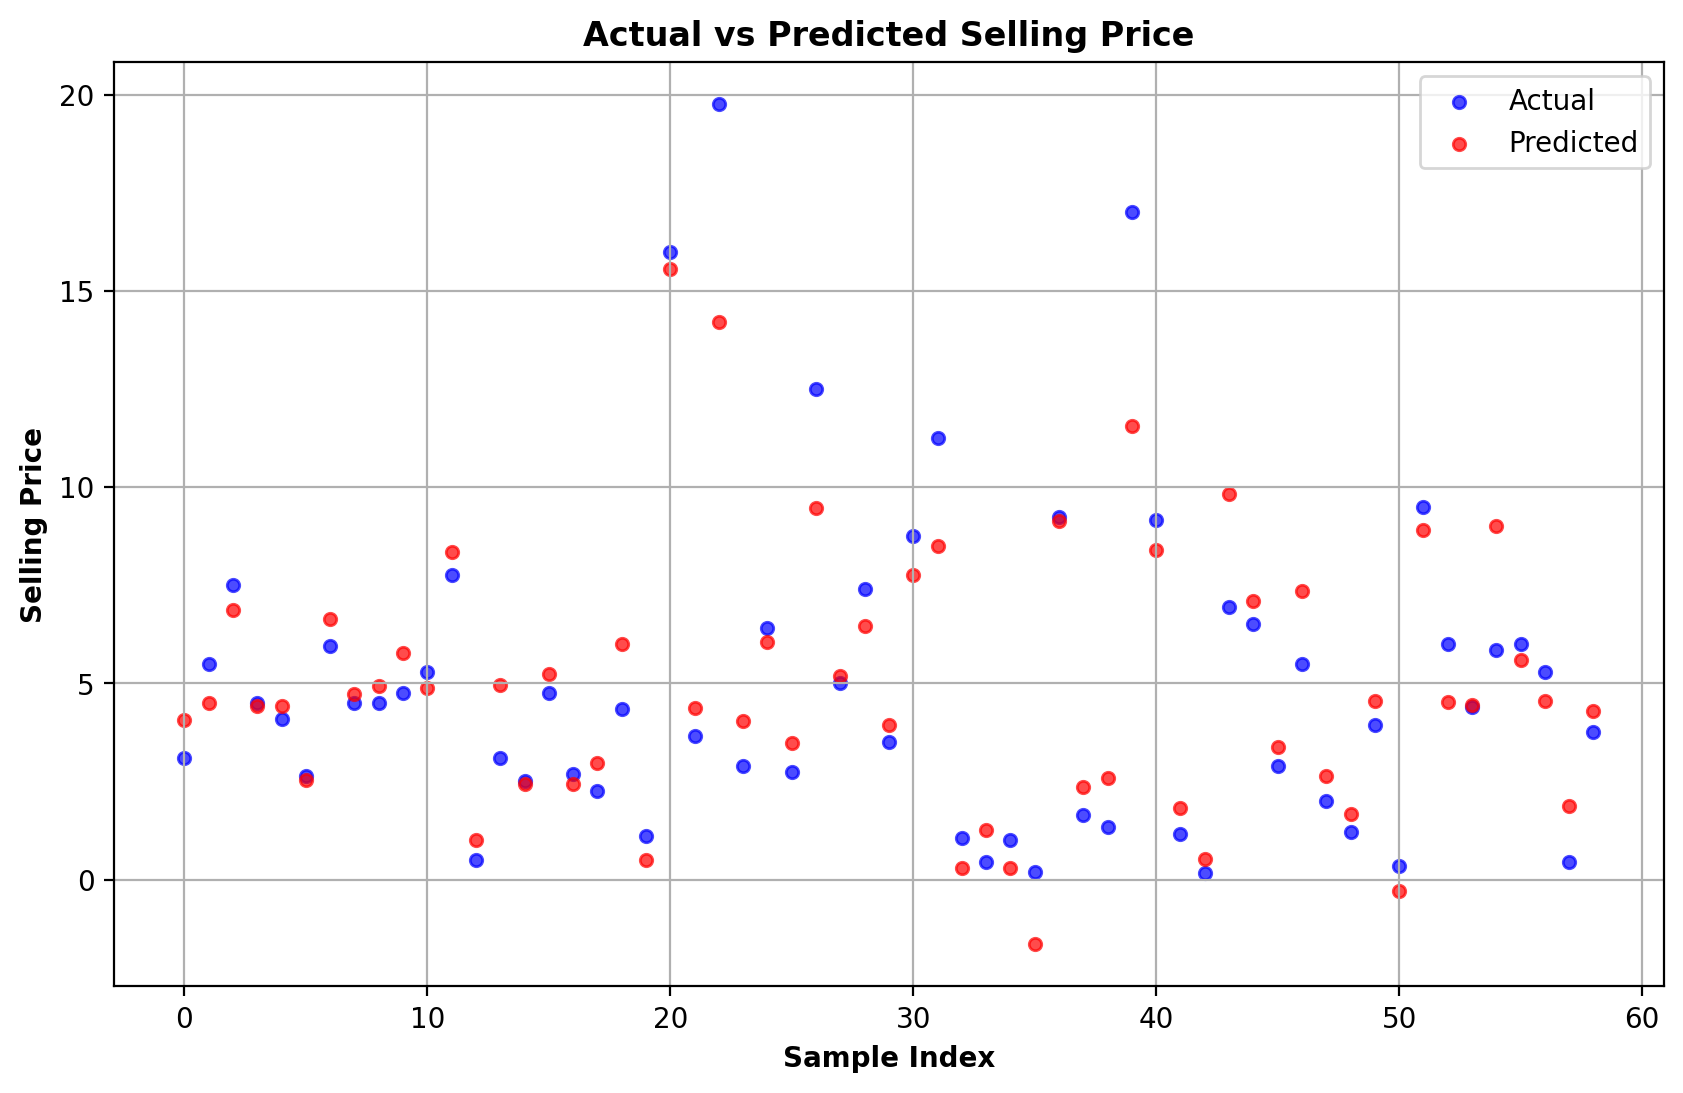

In [56]:
#Actual_vs_Predicted_Selling_Price

plt.figure(figsize=(10,6), dpi=200)

plt.scatter(range(len(y_test)), y_test, color='blue', label='Actual', s=20, alpha=0.7)
plt.scatter(range(len(y_pred)), y_pred, color='red', label='Predicted', s=20, alpha=0.7)

plt.xlabel("Sample Index", weight="bold")
plt.ylabel("Selling Price", weight="bold")
plt.title("Actual vs Predicted Selling Price", weight="bold")
plt.grid(True)
plt.legend()


plt.show()

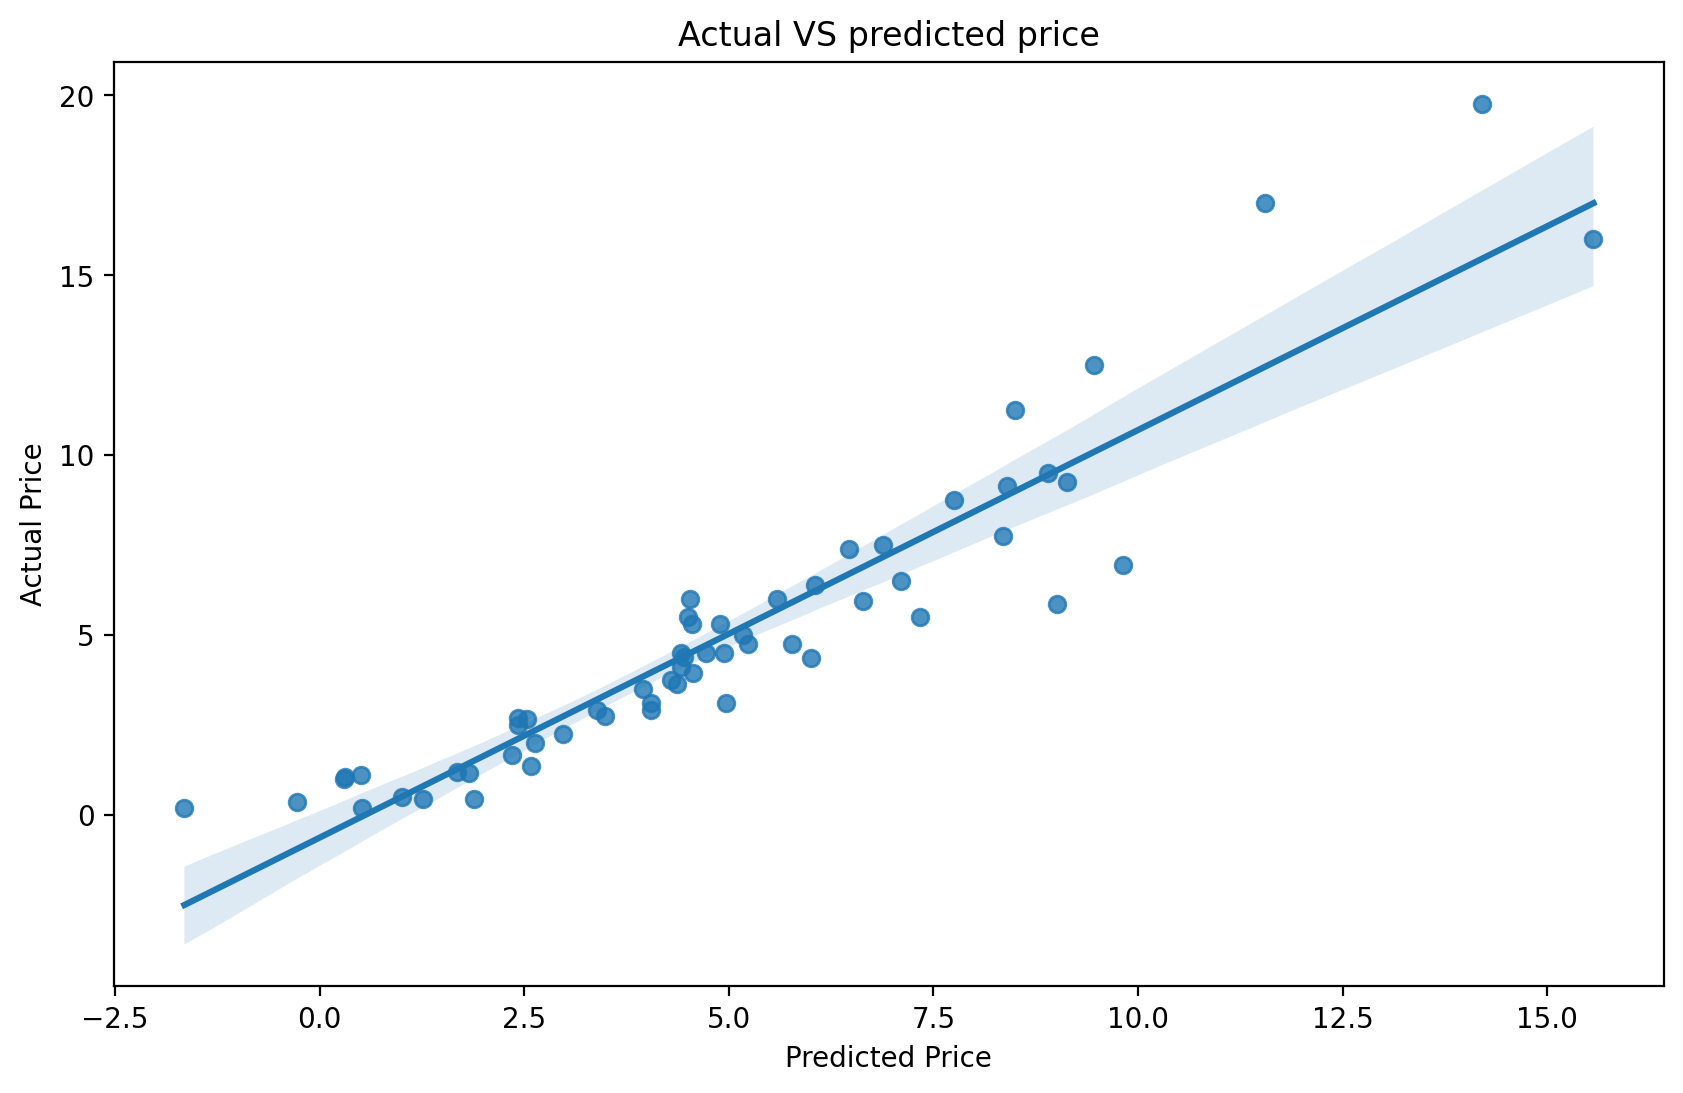

In [57]:
#Actual_Vs_Predict

plt.figure(figsize=(10,6), dpi=200)

sns.regplot(x=y_pred, y=y_test)

plt.xlabel ('Predicted Price')
plt.ylabel ('Actual Price')
plt.title('Actual VS predicted price')
plt.show()

## Prediction of our Sample

### Sample:

| Feature | Value |
|---|---|
| Present_Price | 11.23 |
| Kms_Driven | 42,000 |
| Fuel_Type | Petrol |
| Seller_Type | Dealer |
| Transmission | Manual |
| Owner | 1 |
| Age | 10 |
| Selling_Price | ? |

In [58]:
X_new = pd.DataFrame([{
    'Present_Price': 11.23,
    'Kms_Driven': 42000,
    'Fuel_Type': 'Petrol',
    'Seller_Type': 'Dealer',
    'Transmission': 'Manual',
    'Owner': 1,
    'Age': 10
}])

if best_model_name == 'Present_Price²':
    X_new['Present_Price_square'] = X_new['Present_Price'] ** 2
elif best_model_name == 'Present_Price³':
    X_new['Present_Price_cube'] = X_new['Present_Price'] ** 3

X_new = X_new[X_train_final.columns]
y_predict = final_model.predict(X_new)

print('Predicted price is:', y_predict[0])

Predicted price is: 5.346175416290784


This prediction is illustrative and should not be interpreted as a market valuation.

## Key Findings

- Present Price shows the strongest positive relationship with Selling Price.
- Vehicle Age shows a negative relationship with Selling Price.
- - Kilometers driven (`Kms_Driven`) has a much weaker linear relationship with Selling Price than Present Price does.
- Seller Type, Fuel Type, and Transmission show observable differences in selling price, although these relationships should not be interpreted causally.
- The final model is selected using cross-validation on the training data and evaluated once on the held-out test set.

### Limitations

- The original dataset contains only 301 observations.
- Some categorical groups are highly imbalanced, particularly Fuel Type.
- Extreme observations may influence model performance.
- The model is intended as an educational predictive baseline rather than a production pricing system.